# 从巡航控制看几种基本的控制策略与控制系统的结构

本文档关注车辆巡航控制系统，以及相应的控制方案。
车辆纵向动力学可用一阶微分方程建模。设车重 $m$，空气阻力系数 $c_1$，滚动阻力系数 $c_2$，重力加速度为 $g$，则根据牛顿第二定律运动方程为：
\begin{equation*}
    m\dot v(t) = F(t) - c_1 v^2(t) - c_2 m g  
\end{equation*}
等号右边第一项为车辆发动机提供的驱动力，第二项为空气阻力，第三项为滚动阻力。

在控制理论中，我们通常将控制量（即该例子中的驱动力/制动力）记作 $u$，则该系统的状态空间模型可以表示为：
\begin{align} 
    \dot v(t) = -C_1 v^2(t) - C_2 + \frac{1}{m}\, u(t)
\end{align}
其中，$C_1 = c_1/m$，$C_2 = c_2 g$，$u(t) = F(t)$ 是控制输入。

In [1]:
# Required packages for this notebook: torch, matplotlib, numpy
# If needed, install them with: pip install torch matplotlib numpy

import time
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.titlesize": 16,
})

### 开环控制

设我们希望车辆以恒定速度 $v_{\text{ref}}$ 行驶，并且我们知道车辆的动力学参数 $C_1$ 和 $C_2$以及车辆质量$m$。在开环控制中，我们可以直接计算所需的驱动力 $u_{\text{open}}$ 来维持该速度：
\begin{align*}
    u_{\text{open}} = m C_1 v^2_{\text{ref}} + m C_2
\end{align*}
下面观察，开环系统的表现。

In [2]:
# 定义系统参数与动力学方程
c1 = 0.4
c2 = 0.01  
m = 1200 # Kg
g = 9.8 # m/s^2
C1 = c1 / m 
C2 = c2 * g
v_ref = 20 # m/s
v0 = 0.0  # initial speed

# open loop control
u_open = m * C1 * v_ref ** 2 + m * C2

# 定义开环系统的ode方程
def ode_open(t, x, u_open=u_open, C1=C1, C2=C2, m=m):
    # dx/dt = -C1 * x^2 - C2 + u_open / m

    dxdt = -C1 * x ** 2 - C2 + u_open / m
    return dxdt



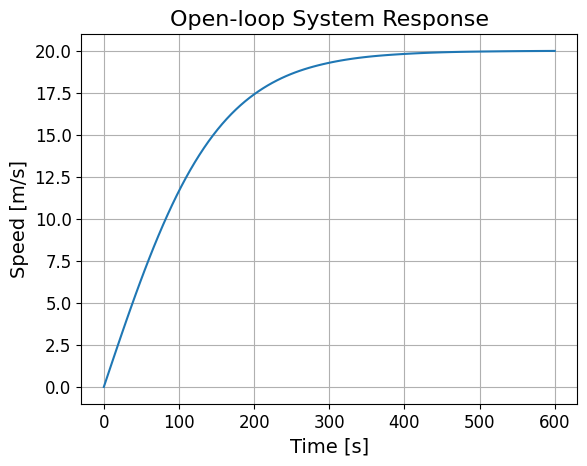

In [3]:
# 对开环系统进行仿真

T = 600.0  # simulation time

t_eval = np.linspace(0, T, 100) # 输出时间
sol = solve_ivp(ode_open, [0, T], [v0], t_eval=t_eval)

# 绘图
plt.figure()
plt.plot(sol.t, sol.y[0])
plt.xlabel('Time [s]')
plt.ylabel('Speed [m/s]')
plt.title('Open-loop System Response')
plt.grid(True)
plt.show()


我们观察一下开环系统的稳定性

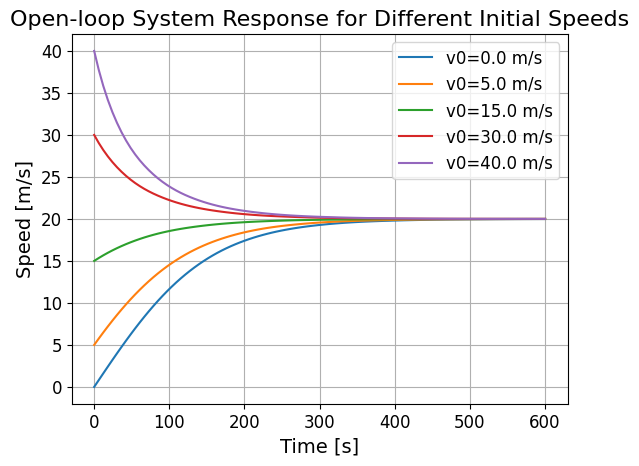

In [4]:
v0_list = [0.0, 5.0, 15.0, 30.0, 40.0]  # initial speeds

for v0 in v0_list:
    sol = solve_ivp(ode_open, [0, T], [v0], t_eval=t_eval)
    plt.plot(sol.t, sol.y[0], label=f'v0={v0} m/s')

plt.xlabel('Time [s]')
plt.ylabel('Speed [m/s]')
plt.title('Open-loop System Response for Different Initial Speeds')
plt.legend()
plt.grid(True)
plt.show()

接下来，我们来观察当系统参数有扰动，系统的表现。

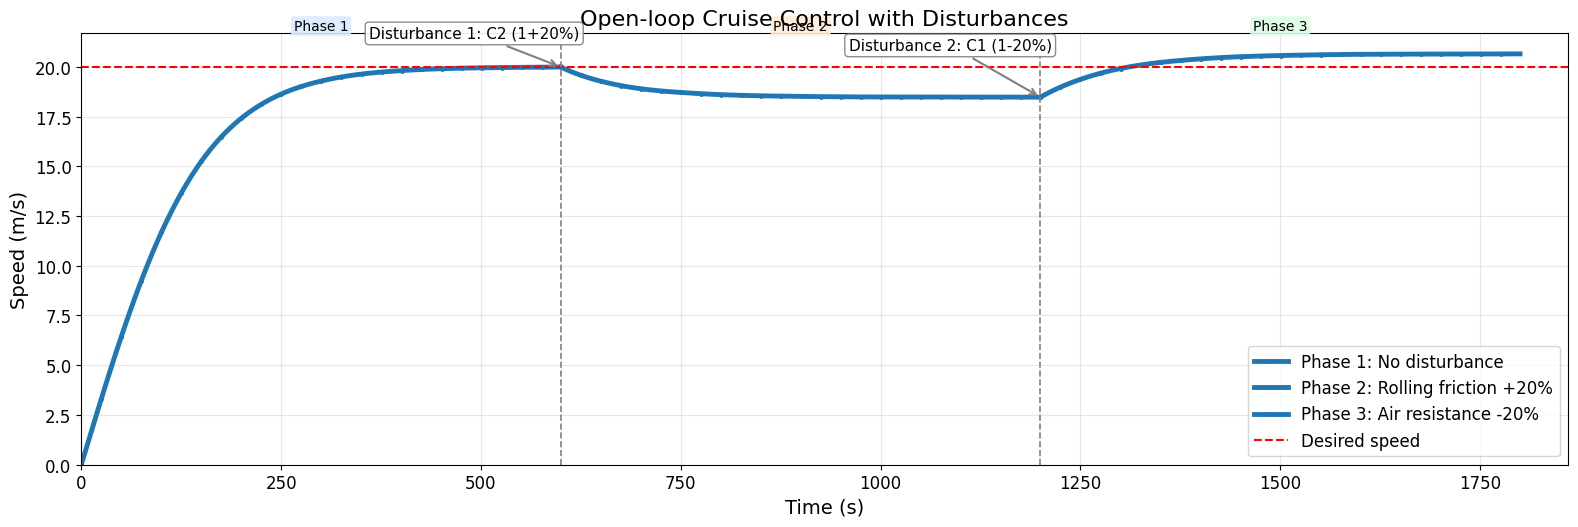

Phase 1 final speed: 19.99 m/s
Phase 2 final speed: 18.47 m/s
Phase 3 final speed: 20.65 m/s


In [5]:
# ============================================================
# 扰动对开环巡航控制系统的影响（分段仿真 + 扰动标注）
# ============================================================

T = 600.0
t_eval = np.linspace(0, T, 600)

# ---- Phase 1: 无扰动 ----
sol = solve_ivp(ode_open, [0, T], [0], t_eval=t_eval)
t1 = sol.t
v1 = sol.y[0]

# ---- Phase 2: 滚动摩擦增加 20% ----
C2_new = C2 * 1.2
v0_2 = v1[-1]

def ode_open_with_larger_rolling_friction(t, y):
    v = y[0]
    dvdt = -C1 * v**2 - C2_new + u_open / m
    return [dvdt]

sol = solve_ivp(ode_open_with_larger_rolling_friction, [0, T], [v0_2], t_eval=t_eval)
t2 = sol.t + T
v2 = sol.y[0]

# ---- Phase 3: 空气阻力减小 20%（在 Phase 2 基础上）----
C1_new = C1 * 0.8
v0_3 = v2[-1]

def ode_open_with_less_air_resistance(t, y):
    v = y[0]
    dvdt = -C1_new * v**2 - C2_new + u_open / m
    return [dvdt]

sol = solve_ivp(ode_open_with_less_air_resistance, [0, T], [v0_3], t_eval=t_eval)
t3 = sol.t + 2 * T
v3 = sol.y[0]

# ---- 作图：把图变长，并标注扰动 ----
plt.figure(figsize=(16, 5.5))

# 加上稀疏标记，方便看到 t_eval 的采样点
plt.plot(t1, v1, label='Phase 1: No disturbance', color='C0', linewidth=3.5, marker='o', markersize=2.5, markevery=25)
plt.plot(t2, v2, label='Phase 2: Rolling friction +20%', color='C0', linewidth=3.5, marker='o', markersize=2.5, markevery=25)
plt.plot(t3, v3, label='Phase 3: Air resistance -20%', color='C0', linewidth=3.5, marker='o', markersize=2.5, markevery=25)

# 目标速度线
plt.axhline(y=v_ref, color='r', linestyle='--', linewidth=1.5, label='Desired speed')

# 扰动切换时刻
switch_1 = T
switch_2 = 2 * T
plt.axvline(switch_1, color='gray', linestyle='--', linewidth=1.2)
plt.axvline(switch_2, color='gray', linestyle='--', linewidth=1.2)

# 扰动文字标注 + 箭头
y_top = max(np.max(v1), np.max(v2), np.max(v3))
plt.annotate('Disturbance 1: C2 (1+20%)',
             xy=(switch_1, v2[0]),
             xytext=(switch_1 - 240, y_top + 0.8),
             arrowprops=dict(arrowstyle='->', color='gray', lw=1.5),
             fontsize=11,
             bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='gray', alpha=0.9))

plt.annotate('Disturbance 2: C1 (1-20%)',
             xy=(switch_2, v3[0]),
             xytext=(switch_2 - 240, y_top + 0.2),
             arrowprops=dict(arrowstyle='->', color='gray', lw=1.5),
             fontsize=11,
             bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='gray', alpha=0.9))

# 分阶段顶部标签
plt.text(T * 0.5, y_top + 1.4, 'Phase 1', ha='center', va='center', fontsize=10,
         bbox=dict(boxstyle='round,pad=0.2', fc='#dbeafe', ec='none', alpha=0.9))
plt.text(T * 1.5, y_top + 1.4, 'Phase 2', ha='center', va='center', fontsize=10,
         bbox=dict(boxstyle='round,pad=0.2', fc='#ffedd5', ec='none', alpha=0.9))
plt.text(T * 2.5, y_top + 1.4, 'Phase 3', ha='center', va='center', fontsize=10,
         bbox=dict(boxstyle='round,pad=0.2', fc='#dcfce7', ec='none', alpha=0.9))

plt.xlabel('Time (s)')
plt.ylabel('Speed (m/s)')
plt.title('Open-loop Cruise Control with Disturbances')
plt.xlim(0, 3 * T + 60)
plt.ylim(bottom=0)
plt.grid(True, alpha=0.3)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f'Phase 1 final speed: {v1[-1]:.2f} m/s')
print(f'Phase 2 final speed: {v2[-1]:.2f} m/s')
print(f'Phase 3 final speed: {v3[-1]:.2f} m/s')

## 闭环控制 —— 积分控制器

In [6]:
# 定义积分控制器 

Ki = 1  # 积分增益

def ode_integral_controller(t, y, Ki=Ki, C1=C1, C2=C2, m=m, v_ref=v_ref):
    v = y[0]
    z = y[1] # 积分误差
    
    # 控制输入 u = Ki * integral_error
    u = Ki * z
    
    dvdt = -C1 * v**2 - C2 + u / m
    dzdt = v_ref - v  # 积分误差的导数
    
    return [dvdt, dzdt]

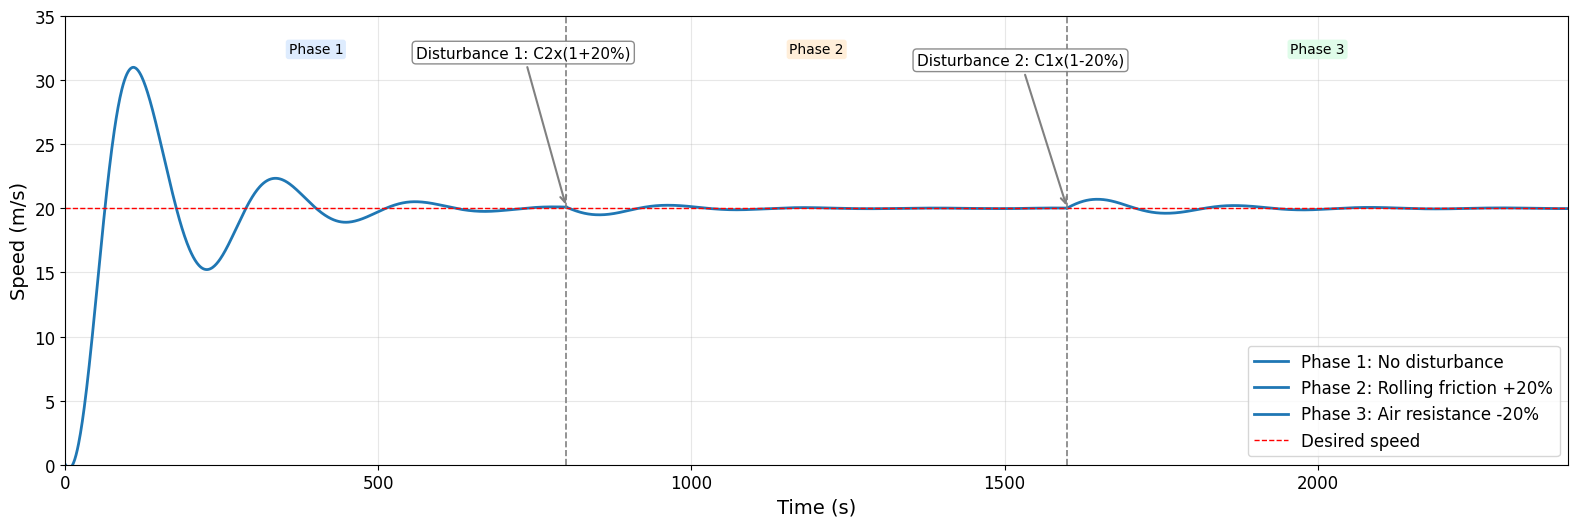

Phase 1 final speed: 20.1 m/s
Phase 2 final speed: 20.0 m/s
Phase 3 final speed: 20.0 m/s


In [7]:
# 效果图

T = 800.0
t_eval = np.linspace(0, T, 800)

# ---- Phase 1: 无扰动 ----
y0 = [0.0, 0.0]  # 初始状态 [v, z]
sol = solve_ivp(ode_integral_controller, [0, T], y0, t_eval=t_eval)
t1 = sol.t
v1 = sol.y[0]
z1 = sol.y[1]

# ---- Phase 2: 滚动摩擦增加 20% ----
C2_new = C2 * 1.2
sol = solve_ivp(ode_integral_controller, [0, T], [v1[-1], z1[-1]], args=(Ki, C1, C2_new, m, v_ref), t_eval=t_eval)
t2 = sol.t + T
v2 = sol.y[0]
z2 = sol.y[1]

# ---- Phase 3: 空气阻力减小 20%（在 Phase 2 基础上）----
C1_new = C1 * 0.8
sol = solve_ivp(ode_integral_controller, [0, T], [v2[-1], z2[-1]], args=(Ki, C1_new, C2_new, m, v_ref), t_eval=t_eval)
t3 = sol.t + 2 * T
v3 = sol.y[0]
z3 = sol.y[1]


# ---- 作图 ----
plt.figure(figsize=(16, 5.5))

plt.plot(t1, v1, label='Phase 1: No disturbance', color='C0', linewidth=2)
plt.plot(t2, v2, label='Phase 2: Rolling friction +20%', color='C0', linewidth=2)
plt.plot(t3, v3, label='Phase 3: Air resistance -20%', color='C0', linewidth=2)

# 目标速度线
plt.axhline(y=v_ref, color='r', linestyle='--', linewidth=1, label='Desired speed')

# 扰动切换时刻
switch_1 = T
switch_2 = 2 * T
plt.axvline(switch_1, color='gray', linestyle='--', linewidth=1.2)
plt.axvline(switch_2, color='gray', linestyle='--', linewidth=1.2)

# 扰动文字标注 + 箭头
y_top = max(np.max(v1), np.max(v2), np.max(v3))
plt.annotate('Disturbance 1: C2x(1+20%)',
             xy=(switch_1, v2[0]),
             xytext=(switch_1 - 240, y_top + 0.8),
             arrowprops=dict(arrowstyle='->', color='gray', lw=1.5),
             fontsize=11,
             bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='gray', alpha=0.9))

plt.annotate('Disturbance 2: C1x(1-20%)',
             xy=(switch_2, v3[0]),
             xytext=(switch_2 - 240, y_top + 0.2),
             arrowprops=dict(arrowstyle='->', color='gray', lw=1.5),
             fontsize=11,
             bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='gray', alpha=0.9))

# 分阶段顶部标签
plt.text(T * 0.5, y_top + 1.4, 'Phase 1', ha='center', va='center', fontsize=10,
         bbox=dict(boxstyle='round,pad=0.2', fc='#dbeafe', ec='none', alpha=0.9))
plt.text(T * 1.5, y_top + 1.4, 'Phase 2', ha='center', va='center', fontsize=10,
         bbox=dict(boxstyle='round,pad=0.2', fc='#ffedd5', ec='none', alpha=0.9))
plt.text(T * 2.5, y_top + 1.4, 'Phase 3', ha='center', va='center', fontsize=10,
         bbox=dict(boxstyle='round,pad=0.2', fc='#dcfce7', ec='none', alpha=0.9))

plt.xlabel('Time (s)')
plt.ylabel('Speed (m/s)')
plt.xlim(0, 3 * T)
plt.ylim(0, 35)
plt.grid(True, alpha=0.3)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f'Phase 1 final speed: {v1[-1]:.1f} m/s')
print(f'Phase 2 final speed: {v2[-1]:.1f} m/s')
print(f'Phase 3 final speed: {v3[-1]:.1f} m/s')




## 闭环控制器———比例-积分控制器

In [ ]:
# 积分控制器定义

Ki = 1  # 积分增益
Kp = 20  # 比例增益


def ode_PI_controller(t, y, Kp=Kp, Ki=Ki, C1=C1, C2=C2, m=m, v_ref=v_ref):
    v = y[0]
    z = y[1]  # 积分误差
    
    # 控制输入 u = Kp * error + Ki * integral_error
    error = v_ref - v
    u = Kp * error + Ki * z
    
    dvdt = -C1 * v**2 - C2 + u / m
    dzdt = error  # 积分误差的导数
    
    return [dvdt, dzdt]

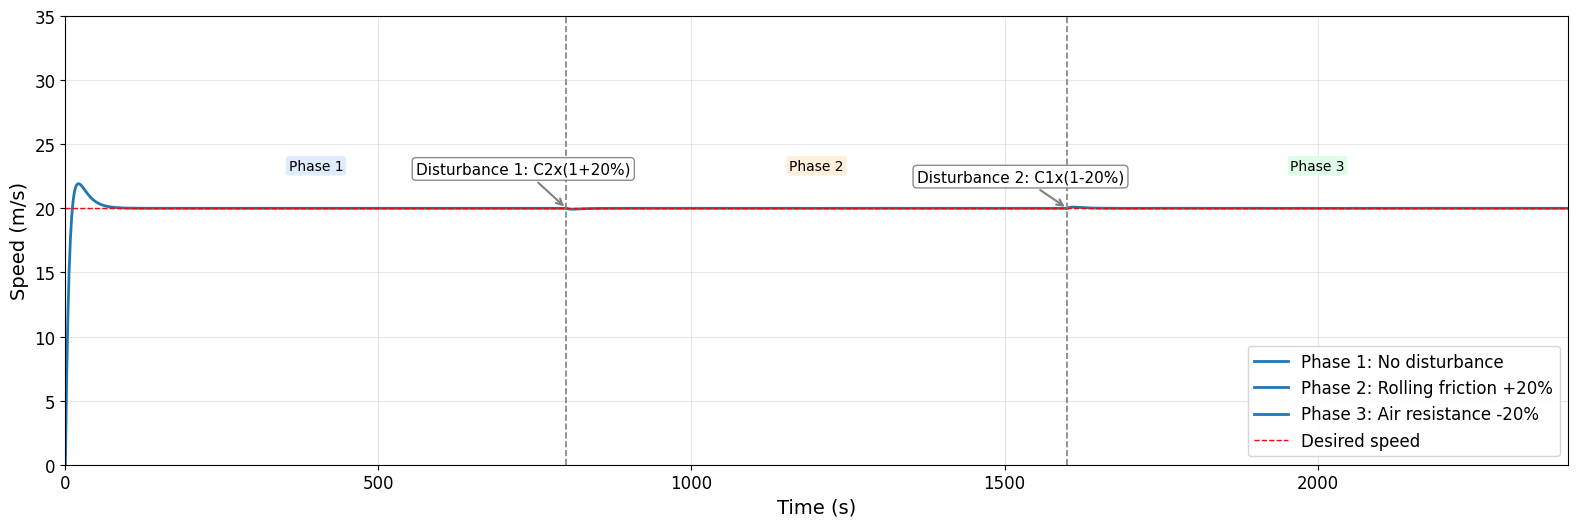

Phase 1 final speed: 20.0 m/s
Phase 2 final speed: 20.0 m/s
Phase 3 final speed: 20.0 m/s


In [20]:
# 效果图

T = 800.0
t_eval = np.linspace(0, T, 800)

# ---- Phase 1: 无扰动 ----
y0 = [0.0, 0.0]  # 初始状态 [v, z]
sol = solve_ivp(ode_PI_controller, [0, T], y0, t_eval=t_eval, max_step=0.1)
t1 = sol.t
v1 = sol.y[0]
z1 = sol.y[1]

# ---- Phase 2: 滚动摩擦增加 20% ----
C2_new = C2 * 1.2
sol = solve_ivp(ode_PI_controller, [0, T], [v1[-1], z1[-1]], args=(Kp, Ki, C1, C2_new, m, v_ref), t_eval=t_eval)
t2 = sol.t + T
v2 = sol.y[0]
z2 = sol.y[1]

# ---- Phase 3: 空气阻力减小 20%（在 Phase 2 基础上）----
C1_new = C1 * 0.8
sol = solve_ivp(ode_PI_controller, [0, T], [v2[-1], z2[-1]], args=(Kp, Ki, C1_new, C2_new, m, v_ref), t_eval=t_eval)
t3 = sol.t + 2 * T
v3 = sol.y[0]
z3 = sol.y[1]


# ---- 作图 ----
plt.figure(figsize=(16, 5.5))

plt.plot(t1, v1, label='Phase 1: No disturbance', color='C0', linewidth=2)
plt.plot(t2, v2, label='Phase 2: Rolling friction +20%', color='C0', linewidth=2)
plt.plot(t3, v3, label='Phase 3: Air resistance -20%', color='C0', linewidth=2)

# 目标速度线
plt.axhline(y=v_ref, color='r', linestyle='--', linewidth=1, label='Desired speed')

# 扰动切换时刻
switch_1 = T
switch_2 = 2 * T
plt.axvline(switch_1, color='gray', linestyle='--', linewidth=1.2)
plt.axvline(switch_2, color='gray', linestyle='--', linewidth=1.2)

# 扰动文字标注 + 箭头
y_top = max(np.max(v1), np.max(v2), np.max(v3))
plt.annotate('Disturbance 1: C2x(1+20%)',
             xy=(switch_1, v2[0]),
             xytext=(switch_1 - 240, y_top + 0.8),
             arrowprops=dict(arrowstyle='->', color='gray', lw=1.5),
             fontsize=11,
             bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='gray', alpha=0.9))

plt.annotate('Disturbance 2: C1x(1-20%)',
             xy=(switch_2, v3[0]),
             xytext=(switch_2 - 240, y_top + 0.2),
             arrowprops=dict(arrowstyle='->', color='gray', lw=1.5),
             fontsize=11,
             bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='gray', alpha=0.9))

# 分阶段顶部标签
plt.text(T * 0.5, y_top + 1.4, 'Phase 1', ha='center', va='center', fontsize=10,
         bbox=dict(boxstyle='round,pad=0.2', fc='#dbeafe', ec='none', alpha=0.9))
plt.text(T * 1.5, y_top + 1.4, 'Phase 2', ha='center', va='center', fontsize=10,
         bbox=dict(boxstyle='round,pad=0.2', fc='#ffedd5', ec='none', alpha=0.9))
plt.text(T * 2.5, y_top + 1.4, 'Phase 3', ha='center', va='center', fontsize=10,
         bbox=dict(boxstyle='round,pad=0.2', fc='#dcfce7', ec='none', alpha=0.9))

plt.xlabel('Time (s)')
plt.ylabel('Speed (m/s)')
plt.xlim(0, 3 * T)
plt.ylim(0, 35)
plt.grid(True, alpha=0.3)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f'Phase 1 final speed: {v1[-1]:.1f} m/s')
print(f'Phase 2 final speed: {v2[-1]:.1f} m/s')
print(f'Phase 3 final speed: {v3[-1]:.1f} m/s')